In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import dynamo as dyn
import pandas as pd
import spateo as st
import scanpy as sc
warnings.filterwarnings('ignore')

import os
import re
import cv2
import random
import numpy as np
import pandas as pd
import glob
import math
import csv
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import distance, transform
from scipy.interpolate import griddata, Rbf
from skimage.io import imread, imshow
import seaborn as sns
import torch
import tifffile as tiff
import anndata as ad
import spateo as st
import dynamo as dyn
from dynamo.tools import sample
import scanpy as sc
# from osgeo import gdal
from numba import cuda
from typing import List
from matplotlib.pyplot import rc_context

c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(

alphashape is not installed. Please install it using 'pip install alphashape'.
fastpd is not installed. Please compile the fastpd library.


c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(

In [2]:
# sample_id = "E7_8h"
# os.chdir(f"/media/pc001/Yao/Projects/Project_drosophila/Data_v4/migration-hotspot/drosophila_{sample_id}_germ_layer_new")
cpo = [(41, 1209, 57), (13, 8, -3), (0, 0, 1)]
cpo = [(800, 1600, 1500), (13, 8, -3), (0, 0, 1)]
cpo = [(1800, -2000, 700),
 (13.0, 8.0, 0),
 (-0.76, -0.65, -0.04)]
# out_image_path = f"image/germband_backbone"
# Path(out_image_path).mkdir(parents=True, exist_ok=True)

In [7]:
def label_match_cells(VA, adata_temp):
    """
    对比 VA.obs 中的 (x, y, z) 与 adata_temp.obs 中的 (centroid_x, centroid_y, centroid_z)
    判断是否存在精确匹配，并在 VA.obs 中添加 'ST' 列，值为 'match' 或 'miss'
    """
    # 获取三维坐标并转换为集合方便匹配
    va_coords = set(map(tuple, VA.obs[['x', 'y', 'z']].round(3).values))
    temp_coords = set(map(tuple, adata_temp.obs[['centroid_x', 'centroid_y', 'centroid_z']].round(3).values))

    # 创建结果列表
    match_status = [('match' if tuple(coord) in temp_coords else 'miss') for coord in VA.obs[['x', 'y', 'z']].round(3).values]

    # 添加到 VA.obs 中
    VA.obs['ST'] = match_status
    return VA

work_path = "G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/doc/Atlas3DbyCT/"
# # 指定文件路径
Atlas3D_norm2nd_path = "G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/ST-bin1/Atlas3D_norm2nd_annoed.h5ad"
Atlas3D_norm2nd = ad.read(Atlas3D_norm2nd_path)

Atlas3D_norm2nd.obs['x'] = Atlas3D_norm2nd.obsm['spatial'][:, 0]
Atlas3D_norm2nd.obs['y'] = Atlas3D_norm2nd.obsm['spatial'][:, 1]
Atlas3D_norm2nd.obs['z'] = Atlas3D_norm2nd.obsm['spatial'][:, 2]

Atlas3D_norm2nd.obs_names_make_unique(join='_')

ST_integrated = ad.read_h5ad(f"G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/ST-bin1/ST_integrated.h5ad")

# 使用replace方法合并多个值到不同的类别
Atlas3D_norm2nd.obs['DV_axis'] = Atlas3D_norm2nd.obs['tissue_anno'].replace({
    "SC": "Dorsal",
    "SC_VA": "Dorsal",

    "CO_VA_1": "Middle",
    "CO_VA_2": "Middle",
    "CO": "Middle",

    "PL": "Middle",
    "SAM": "Middle",

    "VA_joint": "Middle",

    "PL_axis": "Middle",

    "RA_cap": "Middle",
    "RA_stele": "Middle",
    "RA_cortex": "Middle",

    "RA_CR(Coleorhiza)": "Ventral",
    "EP": "Ventral",
    "LS": "Ventral"
})

# print(Atlas3D_norm2nd.obs['DV_axis'].value_counts())

# 使用replace方法合并多个值到不同的类别
Atlas3D_norm2nd.obs['population'] = Atlas3D_norm2nd.obs['tissue_anno'].replace({
    "SC": "majority",
    "CO": "majority",
    "LS": "majority",    
    "RA_CR(Coleorhiza)": "majority",
    "EP": "majority",
    "RA_cortex": "majority",
    "PL": "majority",
    
    "PL_axis": "minority",
    "SC_VA": "minority",
    "RA_stele": "minority",
    "VA_joint": "minority",
    "RA_cap": "minority",
    "CO_VA_2": "minority",
    "CO_VA_1": "minority",
    "SAM": "minority"
})

# print(Atlas3D_norm2nd.obs['population'].value_counts())
# 使用replace方法合并多个值到不同的类别
Atlas3D_norm2nd.obs['tissue_name'] = Atlas3D_norm2nd.obs['tissue_anno'].replace({
    "SC": "SC",
    "CO": "CO",
    "LS": "LS",    
    "RA_CR(Coleorhiza)": "CR",
    "EP": "EP",
    "RA_cortex": "RA_cortex",
    "PL": "PL",
    
    "PL_axis": "PL_axis",
    "SC_VA": "SC_VA",
    "RA_stele": "RA_stele",
    "VA_joint": "VA_joint",
    "RA_cap": "RA_cap",
    "CO_VA_2": "CO_VA_2",
    "CO_VA_1": "CO_VA_1",
    "SAM": "SAM"
})

原始 Subset VA:


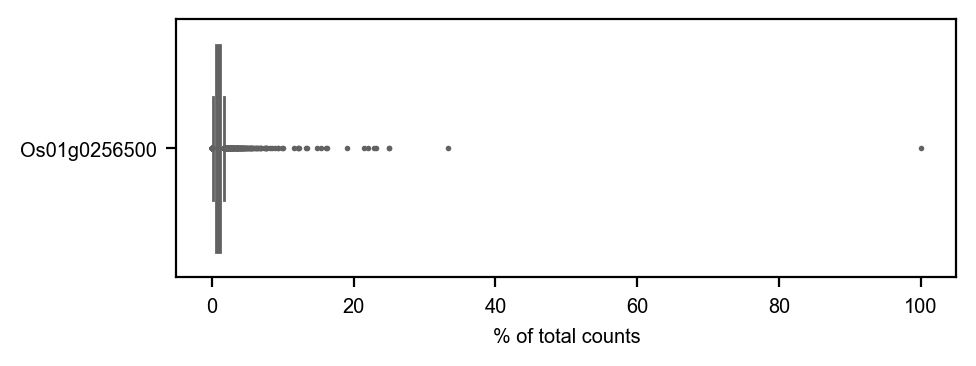

二值化:阈值为0
基因过滤（删除表达为0的基因）
Number of genes removed: 7135
细胞过滤（总counts < 50000000）
NORMLIZATION
batch effect
AnnData object with n_obs × n_vars = 7236 × 22792
    obs: 'anno', 'tissue_anno', 'x', 'y', 'z', 'DV_axis', 'population', 'tissue_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'ST'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'


In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
num = 0  # 阈值
total_counts = 50000000 #
MIN_genes = 0 #删除表达基因数 过低的细胞
MIN_counts = 0 #删除基因表达量 过低的基因
MIN_cells = 1
# =============================================================================
# [1] 选择特定组织区域的数据（子集）
# =============================================================================
VA = Atlas3D_norm2nd[Atlas3D_norm2nd.obs['tissue_anno'].isin(
    ['SC_VA', 'VA_joint', 'CO_VA_1', 'CO_VA_2', 'RA_stele', 'PL_axis']), :]
print("原始 Subset VA:")
# =============================================================================
# [2] 初步QC可视化：高表达基因和violin图展示质控指标
# =============================================================================
sc.pl.highest_expr_genes(VA, n_top=1)

sc.pp.calculate_qc_metrics(VA, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
#     groupby='tissue_anno'
# )
# print(VA)
# =============================================================================
# [3] 表达矩阵二值化：过滤掉低于阈值的表达值
# =============================================================================
X_bin = VA.X.copy()
# num = 0  # 阈值
print(f"二值化:阈值为{num}")

if sparse.issparse(X_bin):
    X_bin = X_bin.tocsr()
    X_bin.data[X_bin.data < num] = 0
    X_bin.eliminate_zeros()  # 去除被设为0的元素
else:
    X_bin[X_bin < num] = 0

# 将二值化后的矩阵存回 VA.X
VA.X = X_bin

# =============================================================================
# [4] 重新计算QC指标，并绘制violin图
# =============================================================================
sc.pp.calculate_qc_metrics(VA, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
# )
# print(VA)

print("基因过滤（删除表达为0的基因）")
# 若VA.X为稀疏矩阵则需要将总和转为数组，否则直接求和
X = VA.X
if sparse.issparse(X):
    total_counts_per_gene = np.array(X.sum(axis=0)).flatten()
else:
    total_counts_per_gene = X.sum(axis=0)

# 仅保留总表达量大于0的基因
genes_to_keep = total_counts_per_gene > 0
VA_filtered = VA[:, genes_to_keep].copy()

print(f"Number of genes removed: {len(VA.var_names) - len(VA_filtered.var_names)}")

# 重新计算质控指标并绘制violin图
sc.pp.calculate_qc_metrics(VA_filtered, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA_filtered,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
# )
# print(VA_filtered)
# =============================================================================
# [6] 细胞过滤（总counts低的或高的细胞过滤，这里只过滤总counts高于5000的细胞）
# =============================================================================
# total_counts = 1500
print(f"细胞过滤（总counts < {total_counts}）")
VA_filtered = VA_filtered[VA_filtered.obs['total_counts'] < total_counts].copy() #删除基因表达量 过高的细胞
sc.pp.filter_cells(VA_filtered, min_genes=MIN_genes) #删除表达基因数 过低的细胞
sc.pp.filter_genes(VA_filtered, min_counts=MIN_counts) #删除基因表达量 过低的基因
sc.pp.filter_genes(VA_filtered, min_cells=MIN_cells)  #删除在MIN_cells个细胞以下表达的基因

# 重新计算QC指标并绘制violin图
sc.pp.calculate_qc_metrics(VA_filtered, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA_filtered,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
# )
# print(VA_filtered)

#####################################################################################################
print(f"NORMLIZATION")
# # VA.layers["counts"] = VA.X.copy()
# # Normalizing to median total counts
# sc.pp.normalize_total(VA_filtered)
# # Logarithmize the data
# sc.pp.log1p(VA_filtered)
# sc.pp.regress_out(VA_filtered, ['total_counts'])
# # 中心化
# sc.pp.scale(VA_filtered, max_value=100)

# # 重新计算QC指标并绘制violin图
# sc.pp.calculate_qc_metrics(VA_filtered, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA_filtered,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
# )
# print(VA_filtered)

#####################################################################################################

# =============================================================================
# [7] 下游分析：高变基因选择、PCA、构建邻接图
# =============================================================================
sc.pp.highly_variable_genes(VA_filtered, n_top_genes=30000)
sc.tl.pca(VA_filtered)
#####################################################################################################
VA_filtered = label_match_cells(VA_filtered, ST_integrated)
print(f"batch effect")
import scanpy.external as sce
# sce.pp.bbknn(VA_filtered, batch_key='ST')
# print(VA_filtered)
# sc.pp.combat(VA_filtered, key='ST')
print(VA_filtered)
# sce.pp.harmony_integrate(VA_filtered, key='ST')
# print(VA_filtered)

# 重新计算QC指标并绘制violin图
sc.pp.calculate_qc_metrics(VA_filtered, percent_top=None, log1p=True, inplace=True)
# sc.pl.violin(
#     VA_filtered,
#     ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'],
#     jitter=0.4,
#     multi_panel=True,
# )
# print(VA_filtered)
#####################################################################################################
# sc.pp.neighbors(VA_filtered, n_neighbors=20, use_rep='X_pca_harmony', n_pcs=50)
sc.pp.neighbors(VA_filtered, n_neighbors=100, n_pcs=50)

# =============================================================================
# [8] 降维及聚类：UMAP、t-SNE和Leiden聚类
# =============================================================================
sc.tl.umap(VA_filtered)
sc.tl.tsne(VA_filtered)
sc.tl.leiden(VA_filtered, flavor="leidenalg", resolution=0.8, n_iterations=2)
sc.tl.leiden(VA_filtered, key_added='leiden_0.1', resolution=0.1)
sc.tl.leiden(VA_filtered, key_added='leiden_0.5', resolution=0.5)
sc.tl.leiden(VA_filtered, key_added='leiden_0.6', resolution=0.6)

# =============================================================================
# [9] t-SNE可视化：展示组织注释、DV_axis及不同分辨率的Leiden聚类结果
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
pt_size = 25

sc.pl.tsne(VA_filtered, legend_loc = 'on data', color='tissue_anno', legend_fontsize=20, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[0, 0])
sc.pl.tsne(VA_filtered, legend_loc = 'on data', color='ST', legend_fontsize=20, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[0, 1])
sc.pl.tsne(VA_filtered, legend_loc = 'on data', color='leiden_0.1', legend_fontsize=18, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[1, 0])
sc.pl.tsne(VA_filtered, legend_loc = 'on data', color='leiden_0.5', legend_fontsize=18, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[1, 1])

plt.subplots_adjust(hspace=0.1, wspace=0.2)
plt.show()

# =============================================================================
# [10] UMAP可视化：展示组织注释、DV_axis及不同分辨率的Leiden聚类结果
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

sc.pl.umap(VA_filtered, legend_loc = 'on data', color='tissue_anno', legend_fontsize=20, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[0, 0])
sc.pl.umap(VA_filtered, legend_loc = 'on data', color='ST', legend_fontsize=20, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[0, 1])
sc.pl.umap(VA_filtered, legend_loc = 'on data', color='leiden_0.1', legend_fontsize=18, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[1, 0])
sc.pl.umap(VA_filtered, legend_loc = 'on data', color='leiden_0.5', legend_fontsize=18, legend_fontweight=10,
           size=pt_size, show=False, ax=axes[1, 1])

plt.subplots_adjust(hspace=0.1, wspace=0.2)
plt.show()

In [33]:
## "/share/org/ZJUFANJL/zju_shangnm/jobdata/Xterm20250414191113/3DAtlasPRJT/output/VA_system.h5ad"
# out_image_path = '/share/org/ZJUFANJL/zju_shangnm/jobdata/Xterm20250414191113/3DAtlasPRJT/output/'
# VA_filtered.write_h5ad(f"{out_image_path}VA_system.h5ad", compression="gzip")
# VA_filtered = st.read_h5ad(f"{out_image_path}VA_system.h5ad")

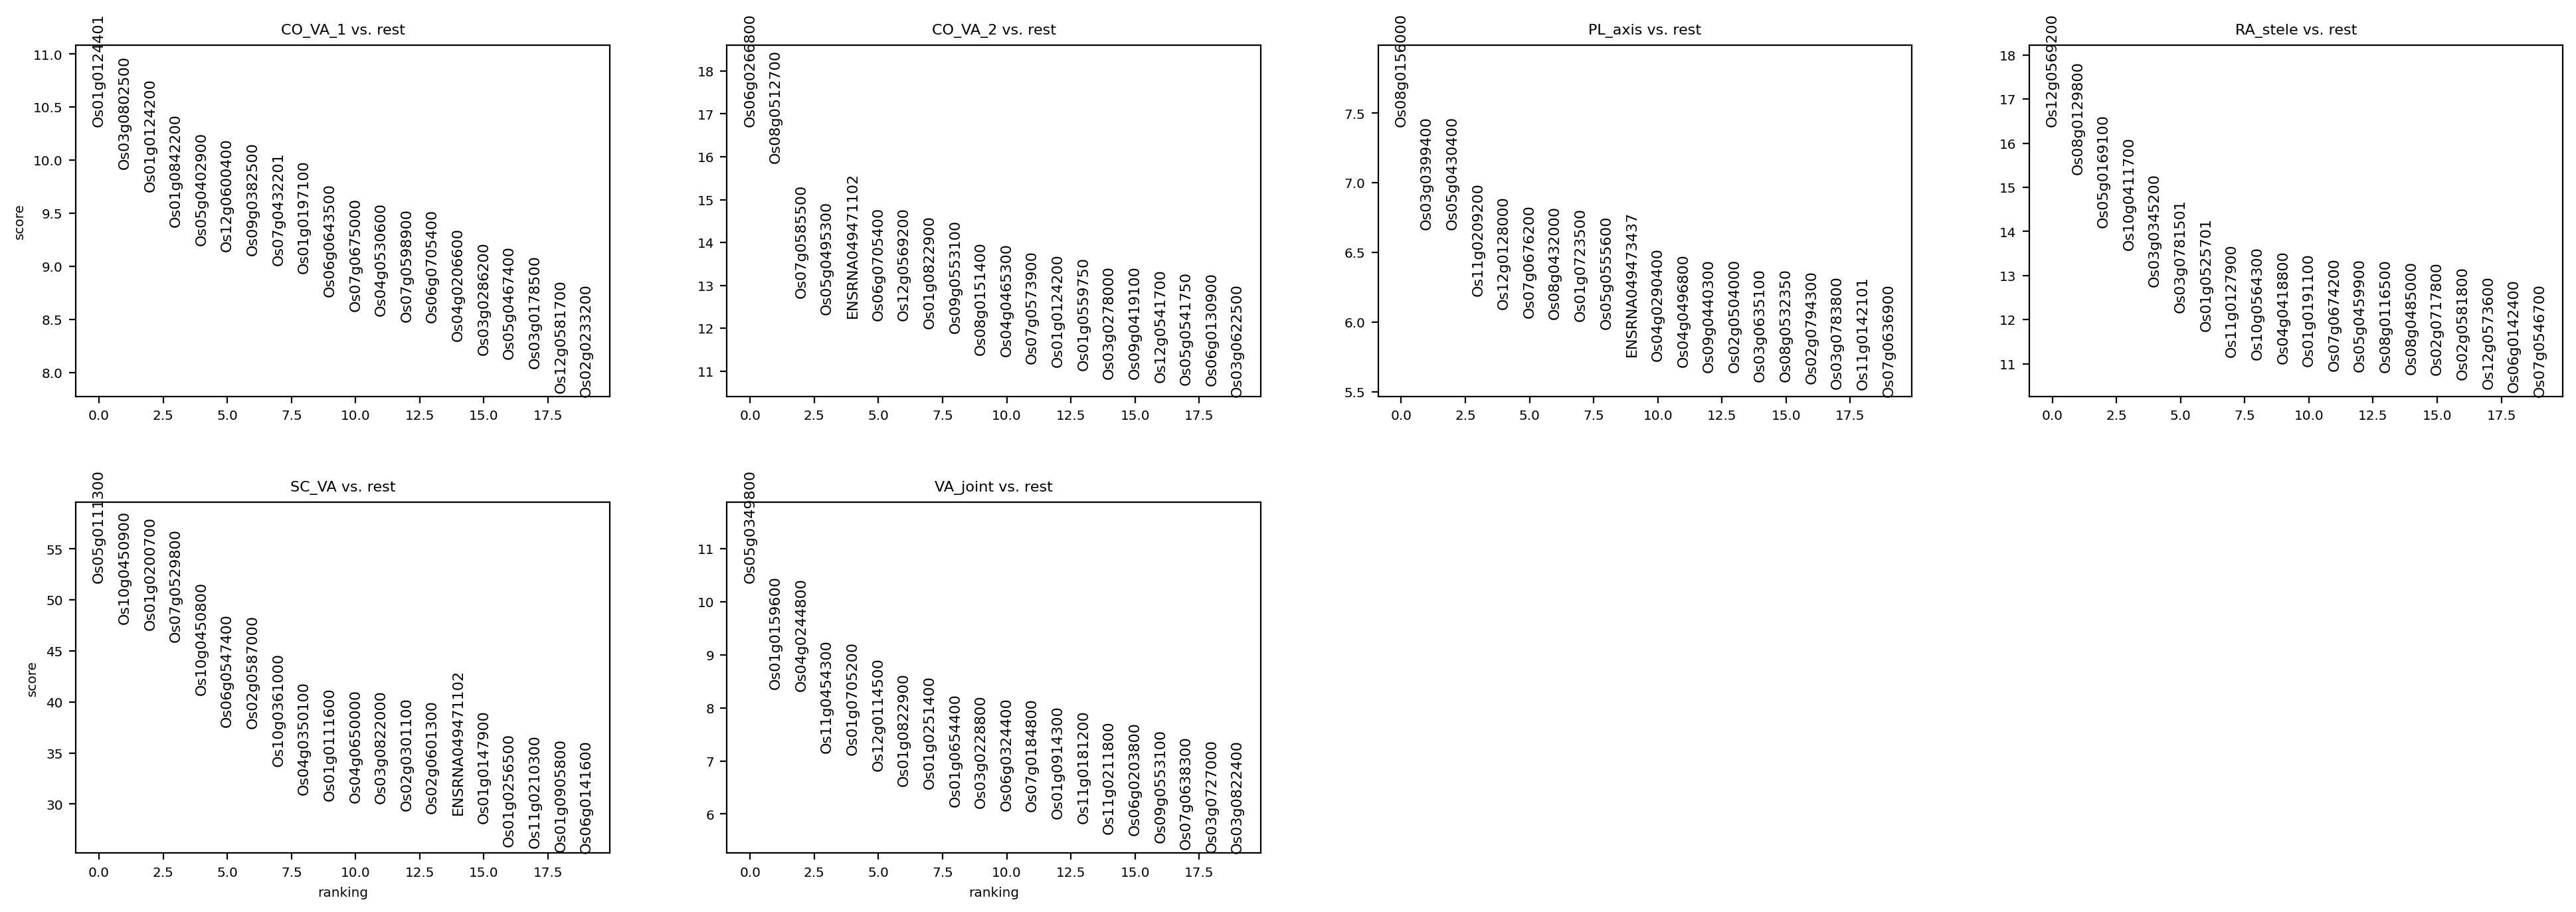

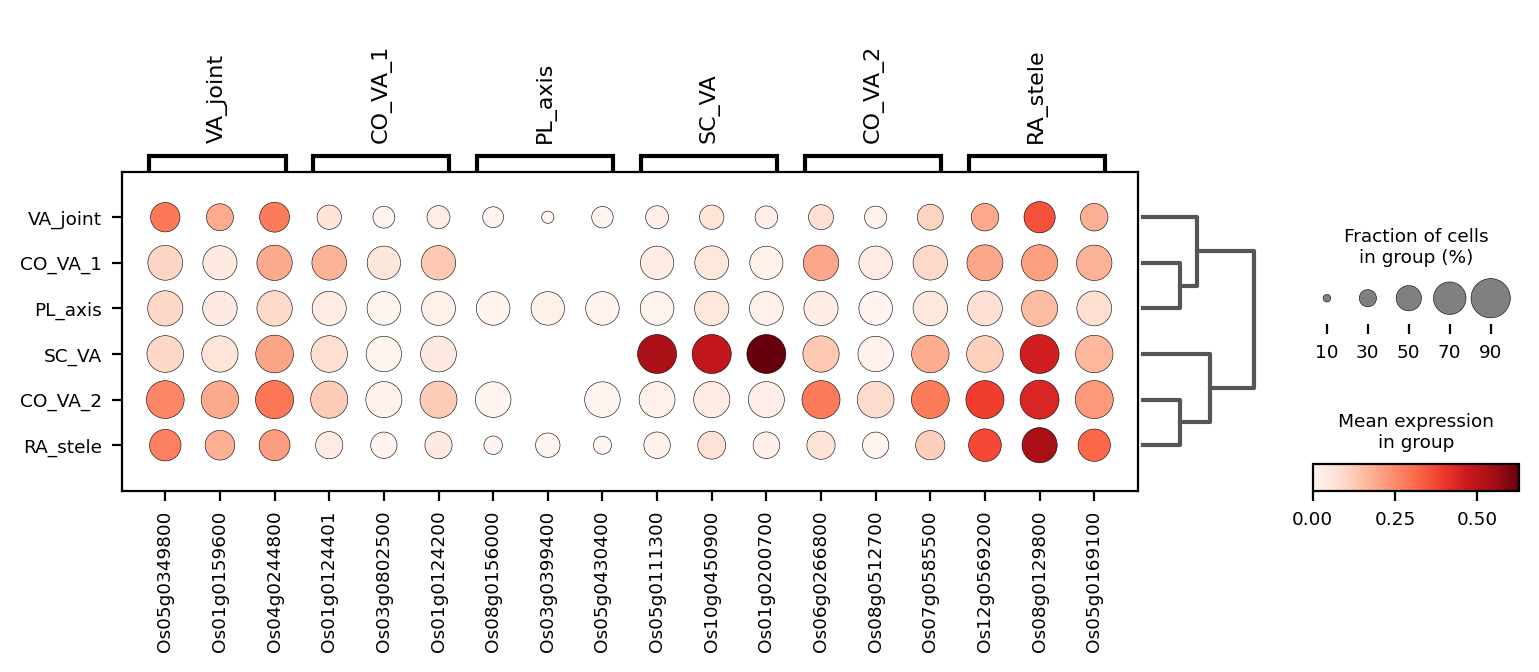

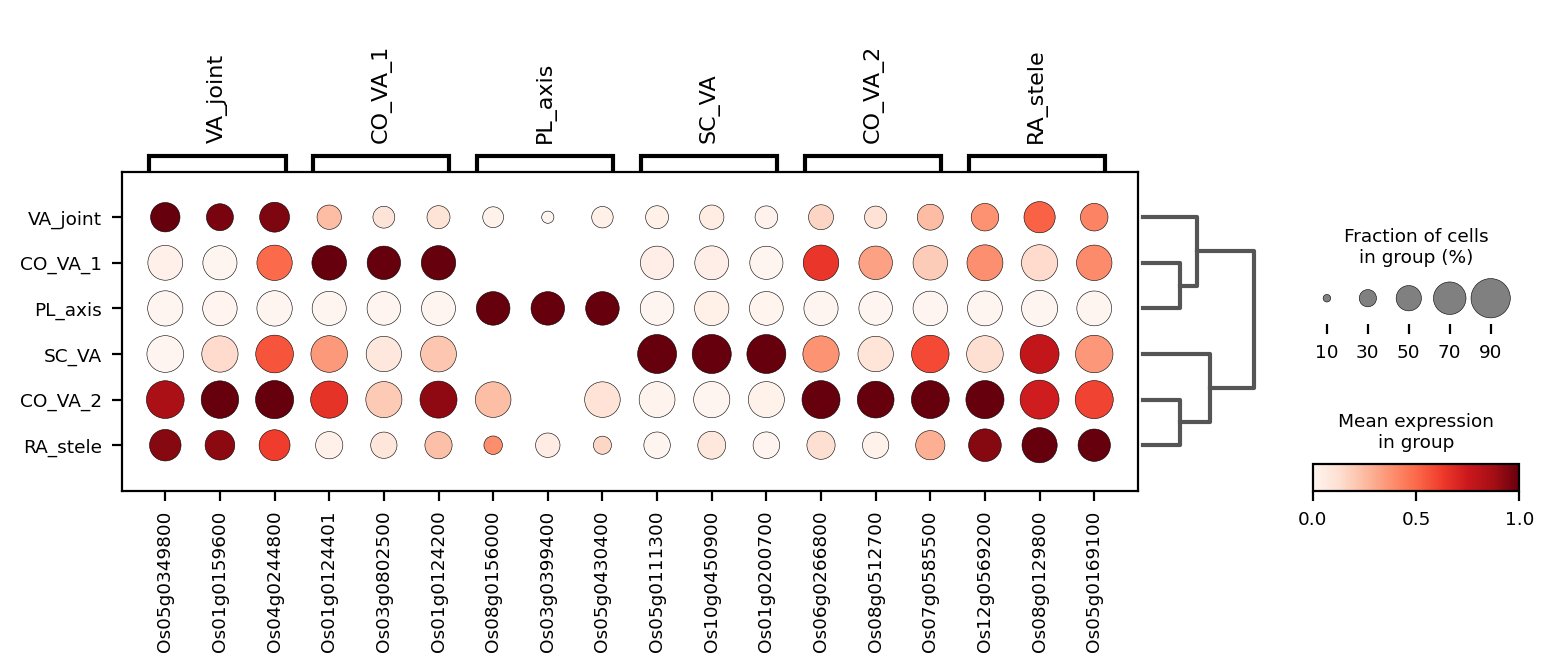

In [6]:
sc.tl.rank_genes_groups(VA_filtered, groupby="tissue_name",  method="t-test_overestim_var", n_genes=VA_filtered.X.shape[1], pts=True)
# sc.tl.rank_genes_groups(VA_filtered, groupby="tissue_name", n_genes=VA_filtered.X.shape[1])
sc.pl.rank_genes_groups(VA_filtered, sharey=False)
sc.pl.rank_genes_groups_dotplot(VA_filtered, groupby="tissue_name", n_genes=3)
sc.pl.rank_genes_groups_dotplot(VA_filtered, groupby="tissue_name", n_genes=3, standard_scale='var')
# sc.pl.rank_genes_groups_dotplot(VA_filtered, groupby="tissue_name", n_genes=3, min_logfoldchange= 0.25)
# sc.pl.rank_genes_groups_dotplot(VA_filtered, groupby="tissue_name", n_genes=3, standard_scale='var', min_logfoldchange= 0.25)

In [15]:
rank_results = VA_filtered.uns['rank_genes_groups']
 
all_groups_results = pd.DataFrame()
 
group_labels = VA_filtered.obs[rank_results['params']['groupby']].unique()
for group_label in group_labels:
    group_df = sc.get.rank_genes_groups_df(VA_filtered, group=group_label)
    group_df = group_df.sort_values(by="scores", ascending=False)
    # group_df = group_df[abs(group_df['logfoldchanges']) >= 0.25]
    group_df['group'] = group_label
    all_groups_results = pd.concat([all_groups_results, group_df], ignore_index=True)

all_groups_results.to_csv(f'{work_path}/output/VA_DEG_all_groups.csv', index=False)


In [ ]:
VA_side = VA_filtered[VA_filtered.obs['tissue_anno'].isin(
    ['VA_joint','CO_VA_1', 'CO_VA_2']), :]
germ_adata = VA_side.copy()
germ_adata.layers["X_counts"]=VA_side.X.copy()
germ_pc, _ = st.tdr.construct_pc(
    adata=germ_adata.copy(),
    spatial_key="spatial",
    groupby="tissue_name",
    key_added="tissue",
    colormap={"CO_VA_1": "#ea5545", "CO_VA_2": "#27aeef", "VA_joint": "#f46a9b", },
)

In [ ]:
## Calculate the Backbone of drosophila germ layer
st.tdr.add_model_labels(model=germ_pc, labels=["Germ Layer Point Clouds"]*germ_pc.n_points, key_added="backbone", where="point_data",inplace=True, alphamap=0.4, colormap="gainsboro")
_germ_pc = germ_pc

In [ ]:
out_image_path = f'{work_path}output/'
sample_id = 'VA_side_nocombat'

In [ ]:
backbone, backbone_length, _ = st.tdr.construct_backbone(
    model=_germ_pc,
    color="orangered",
    num_nodes=40,
    rd_method="ElPiGraph",
    topology="curve",
    Lambda=1e-2,
    Mu=1,
)
st.pl.backbone(
    backbone_model=backbone,
    bg_model=germ_pc,
    bg_key="backbone",
    jupyter="static",
    cpo=cpo,
    filename=os.path.join(out_image_path, f"{sample_id}_germband_backbone_model_raw_labels.pdf")
)

In [15]:
# updated_backbone = st.tdr.update_backbone(backbone=backbone, interactive=True)
updated_backbone = backbone
updated_backbone.point_data["updated_nodes"] = np.asarray([updated_backbone.n_points-1 - i for i in range(updated_backbone.n_points)])
# st.pl.backbone(
#     backbone_model=updated_backbone,
#     bg_model=germ_pc,
#     bg_key="backbone",
#     nodes_key="updated_nodes",
#     jupyter="static",
#     cpo=cpo,
#     filename=os.path.join(out_image_path, f"{sample_id}_germband_backbone_model_labels.pdf")
# )

In [16]:
# updated_backbone = st.tdr.read_model(f"pc_models/Germband_{sample_id}_aligned_backbone_model.vtk")
st.tdr.map_points_to_backbone(
    model=germ_pc,
    backbone_model=updated_backbone,
    nodes_key="updated_nodes",
    key_added="backbone_nodes",
    inplace=True,
)
# st.pl.backbone(
#     backbone_model=updated_backbone,
#     backbone_model_size=10,
#     backbone_key="updated_nodes",
#     backbone_colormap="black",
#     nodes_key="updated_nodes",
#     nodes_label_size=20,
#     bg_model=germ_pc,
#     bg_key="backbone_nodes",
#     bg_colormap="vlag",
#     bg_model_size=14,
#     bg_opacity=0.4,
#     jupyter="static",
#     cpo=cpo,
#     window_size=(2560, 2048),
#     filename=os.path.join(out_image_path, f"{sample_id}_germband_pc_backbone_model_with_labels.pdf")
# )

In [ ]:
# st.pl.backbone(
#     backbone_model=updated_backbone,
#     backbone_model_size=10,
#     backbone_key="updated_nodes",
#     backbone_colormap="black",
#     nodes_key=None,
#     bg_model=germ_pc,
#     bg_key="backbone_nodes",
#     bg_colormap="vlag",
#     bg_model_size=14,
#     bg_opacity=0.4,
#     jupyter="static",
#     cpo=cpo,
#     window_size=(2560, 2048),
#     filename=os.path.join(out_image_path, f"{sample_id}_germband_pc_backbone_model.pdf")
# )

In [20]:
obs_index = np.asarray(germ_pc.point_data["obs_index"])
germ_adata = germ_adata[obs_index, :].copy()
germ_adata.obs["backbone_nodes"] = np.asarray(germ_pc.point_data["backbone_nodes"])
germ_adata.X= germ_adata.layers["X_counts"].copy()
germ_adata.write_h5ad(f"{out_image_path}{sample_id}_v2.h5ad", compression="gzip")

st.tdr.save_model(model=germ_pc, filename=f"{out_image_path}{sample_id}_aligned_pc_model.vtk")
st.tdr.save_model(model=updated_backbone, filename=f"{out_image_path}{sample_id}_aligned_model.vtk")
germ_adata

AnnData object with n_obs × n_vars = 2428 × 22792
    obs: 'anno', 'tissue_anno', 'x', 'y', 'z', 'DV_axis', 'population', 'tissue_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'ST', 'leiden', 'leiden_0.1', 'leiden_0.5', 'leiden_0.6', 'backbone_nodes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_0.1', 'leiden_0.5', 'leiden_0.6', 'tissue_anno_colors', 'ST_colors', 'leiden_0.1_colors', 'leiden_0.5_colors', 'rank_genes_groups', 'dendrogram_tissue_name'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'distances', 'connectivities'

In [ ]:
germ_adata.uns

In [21]:
germ_adata = st.read_h5ad(f"{out_image_path}{sample_id}_v2.h5ad")
germ_pc = st.tdr.read_model(f"{out_image_path}{sample_id}_aligned_pc_model.vtk")
backbone = st.tdr.read_model(f"{out_image_path}{sample_id}_aligned_model.vtk")
germ_adata

AnnData object with n_obs × n_vars = 2428 × 22792
    obs: 'anno', 'tissue_anno', 'x', 'y', 'z', 'DV_axis', 'population', 'tissue_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'ST', 'leiden', 'leiden_0.1', 'leiden_0.5', 'leiden_0.6', 'backbone_nodes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'ST_colors', 'dendrogram_tissue_name', 'hvg', 'leiden', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'neighbors', 'pca', 'rank_genes_groups', 'tissue_anno_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

In [22]:
germ_adata.X= germ_adata.layers["X_counts"].copy()
# sc.pp.normalize_total(germ_adata)
# sc.pp.log1p(germ_adata)

In [23]:
st.tl.glm_degs(
    adata=germ_adata,
    fullModelFormulaStr=f'~cr(backbone_nodes, df=3)',
    key_added="glm_degs",
    qval_threshold=0.05,
    llf_threshold=0
)
print(germ_adata.uns["glm_degs"]["glm_result"])

|-----? Gene expression matrix must be normalized by the size factor, please check if the input gene expression matrix is correct.If you don't have the size factor normalized gene expression matrix, please run `dynamo.pp.normalize_cell_expr_by_size_factors(skip_log = True)`.
|-----> [Detecting genes via Generalized Additive Models (GAMs)] in progress: 100.0000%
|-----> [Detecting genes via Generalized Additive Models (GAMs)] finished [777.6897s]
             status family  log-likelihood          pval          qval
Os03g0767800     ok    NB2     -219.757034  1.473838e-34  3.359173e-30
Os03g0178500     ok    NB2     -152.967987  9.287849e-33  1.058443e-28
Os12g0157000     ok    NB2     -107.258682  2.119576e-27  1.610312e-23
Os07g0432201     ok    NB2      -99.416214  2.789587e-26  1.589506e-22
Os03g0286200     ok    NB2     -114.532822  1.499166e-22  6.833798e-19
...             ...    ...             ...           ...           ...
Os02g0620100     ok    NB2      -17.250042  5.207938e

In [24]:
glm_data = germ_adata.uns["glm_degs"]["glm_result"]
glm_data= glm_data.loc[glm_data["log-likelihood"] >= -2500, :]
glm_data= glm_data.loc[glm_data["pval"] <= 1e-10, :]

In [25]:
print(germ_adata.uns["glm_degs"]["glm_result"])

             status family  log-likelihood          pval          qval
Os03g0767800     ok    NB2     -219.757034  1.473838e-34  3.359173e-30
Os03g0178500     ok    NB2     -152.967987  9.287849e-33  1.058443e-28
Os12g0157000     ok    NB2     -107.258682  2.119576e-27  1.610312e-23
Os07g0432201     ok    NB2      -99.416214  2.789587e-26  1.589506e-22
Os03g0286200     ok    NB2     -114.532822  1.499166e-22  6.833798e-19
...             ...    ...             ...           ...           ...
Os02g0620100     ok    NB2      -17.250042  5.207938e-03  4.999971e-02
Os02g0832301     ok    NB2      -17.250042  5.207938e-03  4.999971e-02
Os05g0373300     ok    NB2      -17.250042  5.207938e-03  4.999971e-02
Os07g0682850     ok    NB2      -17.250042  5.207938e-03  4.999971e-02
Os11g0202400     ok    NB2      -17.250042  5.207938e-03  4.999971e-02

[2372 rows x 5 columns]


In [27]:
print(glm_data)

             status family  log-likelihood          pval          qval
Os03g0767800     ok    NB2     -219.757030  1.473838e-34  3.359173e-30
Os03g0178500     ok    NB2     -152.967990  9.287849e-33  1.058443e-28
Os12g0157000     ok    NB2     -107.258680  2.119576e-27  1.610312e-23
Os07g0432201     ok    NB2      -99.416214  2.789587e-26  1.589506e-22
Os03g0286200     ok    NB2     -114.532820  1.499166e-22  6.833798e-19
...             ...    ...             ...           ...           ...
Os02g0106700     ok    NB2      -70.177060  6.847744e-11  1.773848e-08
Os05g0158400     ok    NB2      -56.597992  6.924496e-11  1.773848e-08
Os11g0520950     ok    NB2      -57.675370  6.926661e-11  1.773848e-08
Os02g0139400     ok    NB2      -69.994720  7.853077e-11  1.988748e-08
Os02g0621700     ok    NB2     -209.133130  8.612552e-11  2.157113e-08

[89 rows x 5 columns]


In [28]:
# # type(glm_data)
save_path = os.path.join(out_image_path, f"VA_{sample_id}_log.csv")
glm_data.to_csv(save_path, index=True)
glm_data = pd.read_csv(save_path, index_col=0)

In [29]:
germ_adata.write_h5ad(f"{out_image_path}{sample_id}_v3.h5ad", compression="gzip")

Saving figure to /share/org/ZJUFANJL/zju_shangnm/jobdata/Xterm20250414191113/3DAtlasPRJT/output/VA_side_nocombat_degs_fit_chunk_1.pdf...


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 35 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'G', 'O', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'five', 'four', 'g', 'i', 'k', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 42, 50, 66, 68, 69, 70, 71, 72, 74, 76, 78, 80, 81, 82, 83, 85, 86, 88, 91]
INFO:fontTools.subset:Closed glyph list over 'MATH': 35 glyphs after
INFO:fontTools.subset:Glyph

Done


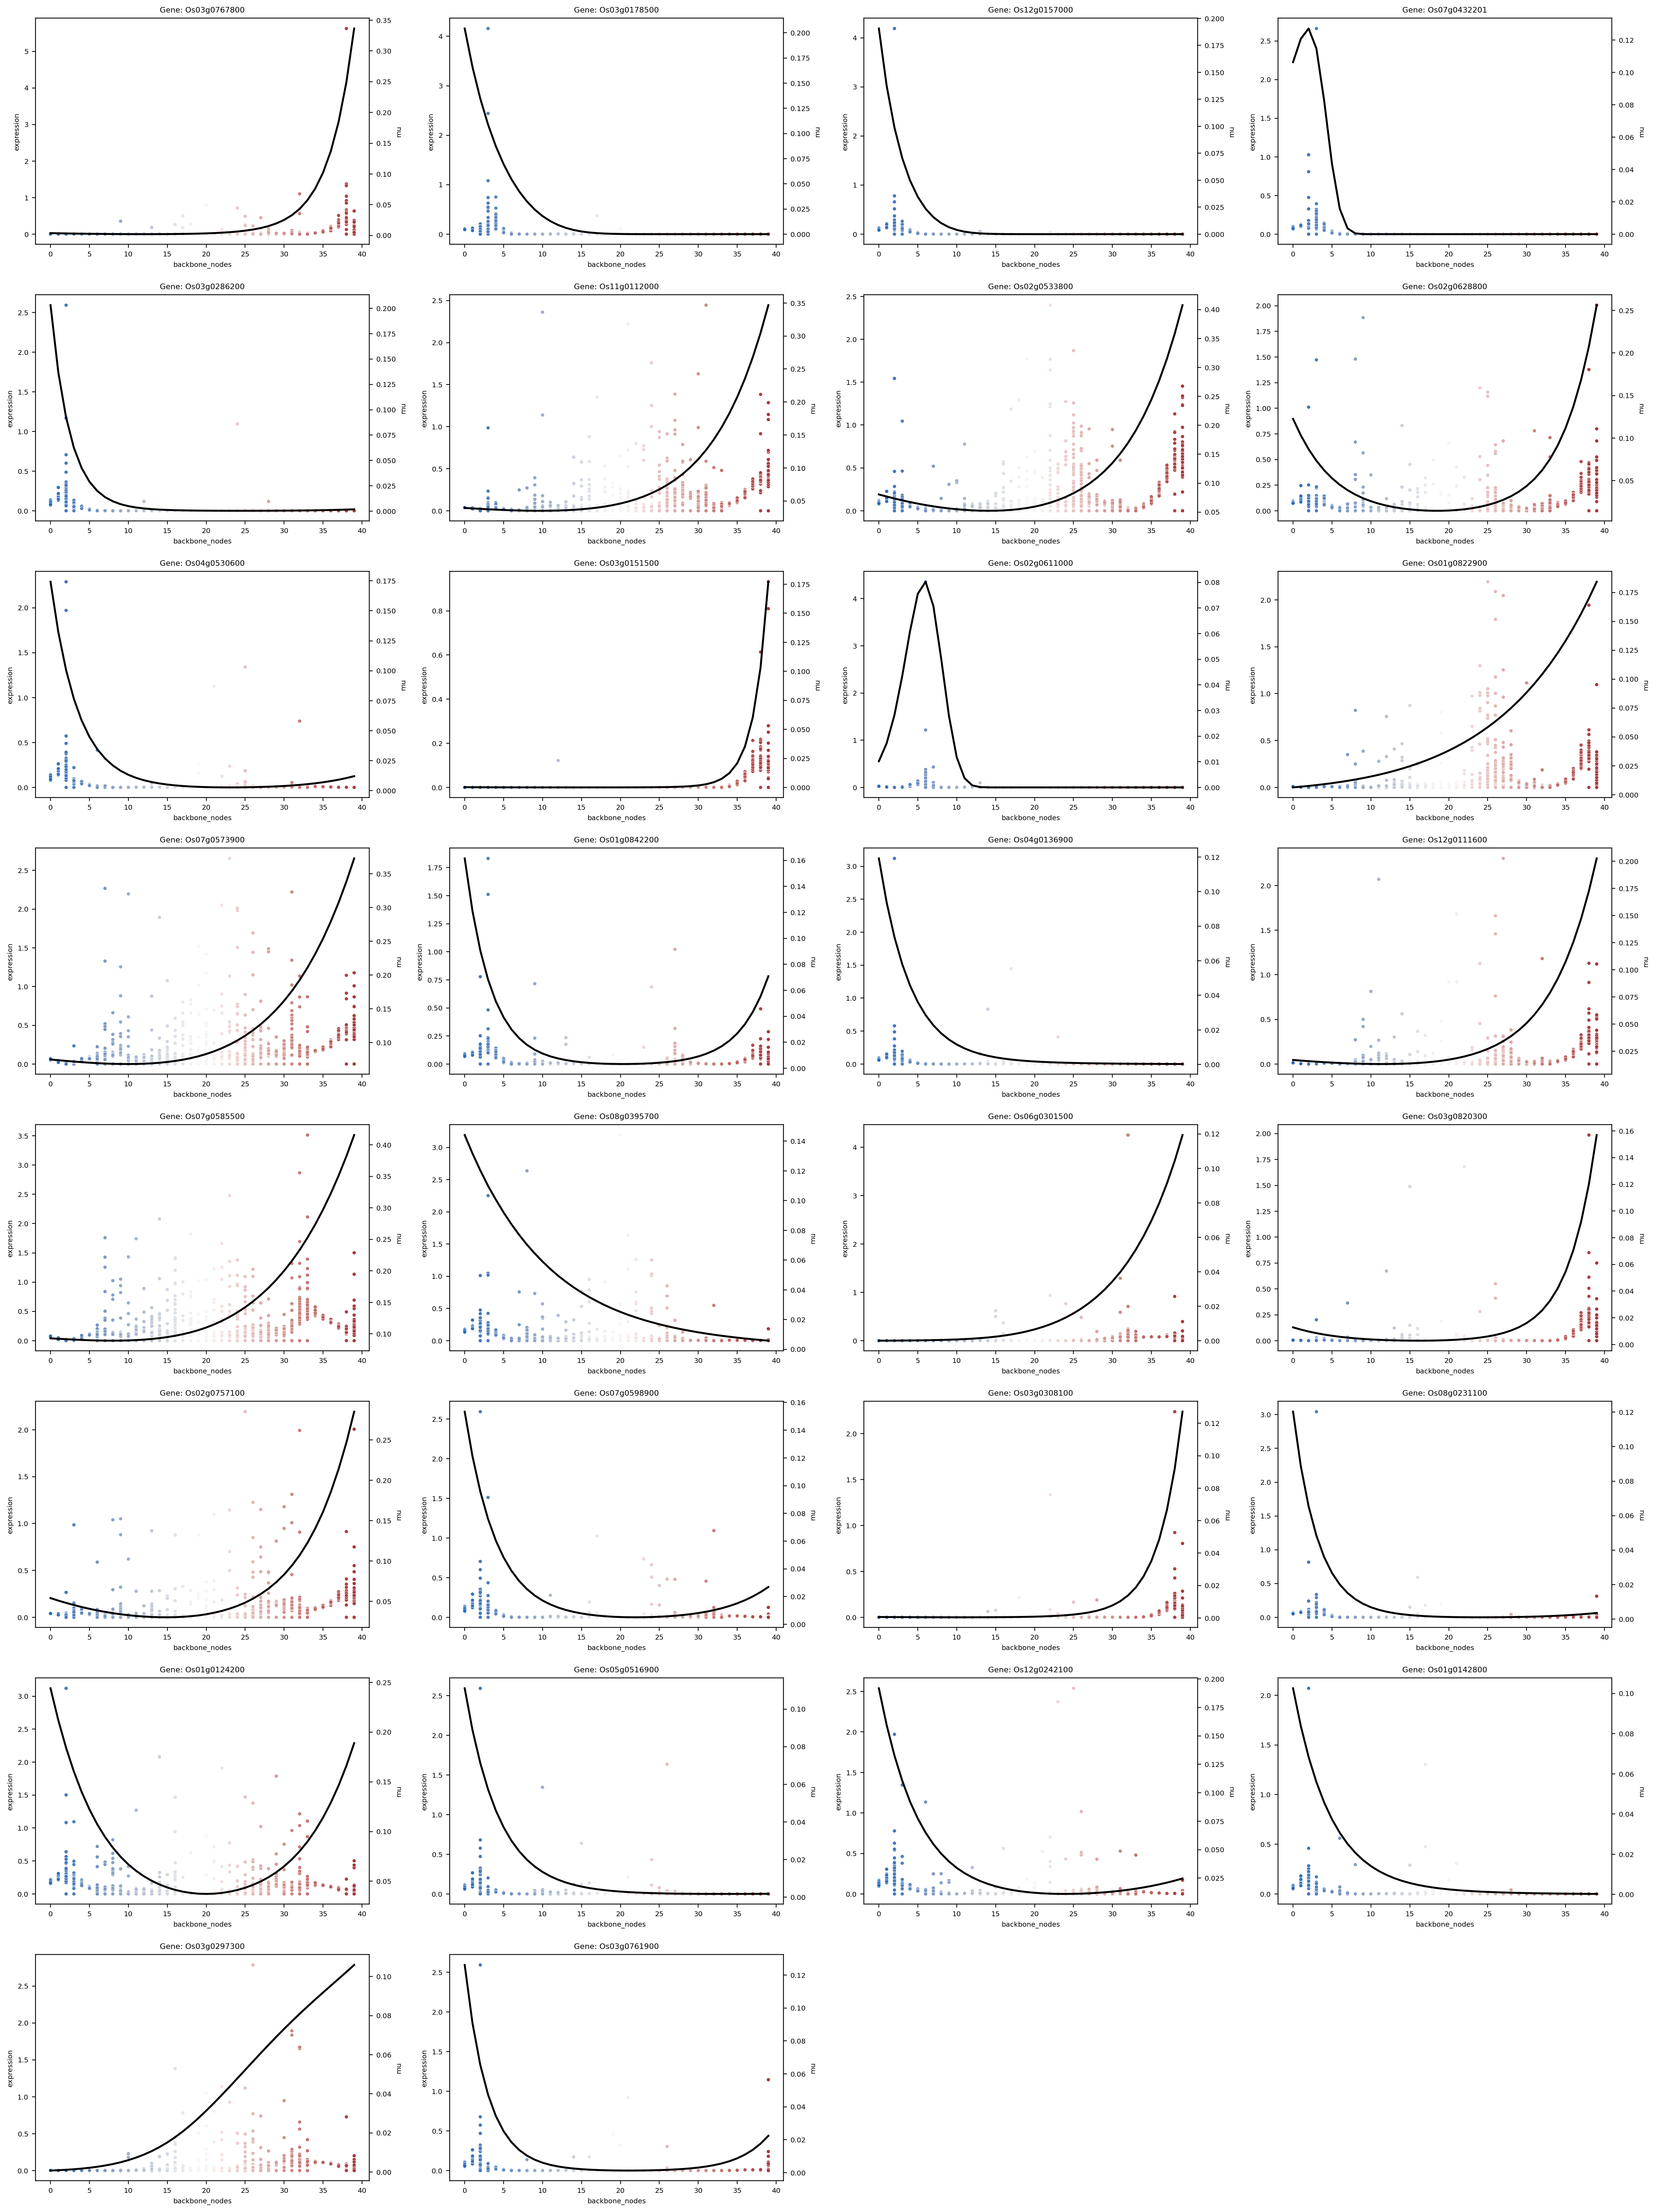

Saving figure to /share/org/ZJUFANJL/zju_shangnm/jobdata/Xterm20250414191113/3DAtlasPRJT/output/VA_side_nocombat_degs_fit_chunk_2.pdf...
Done


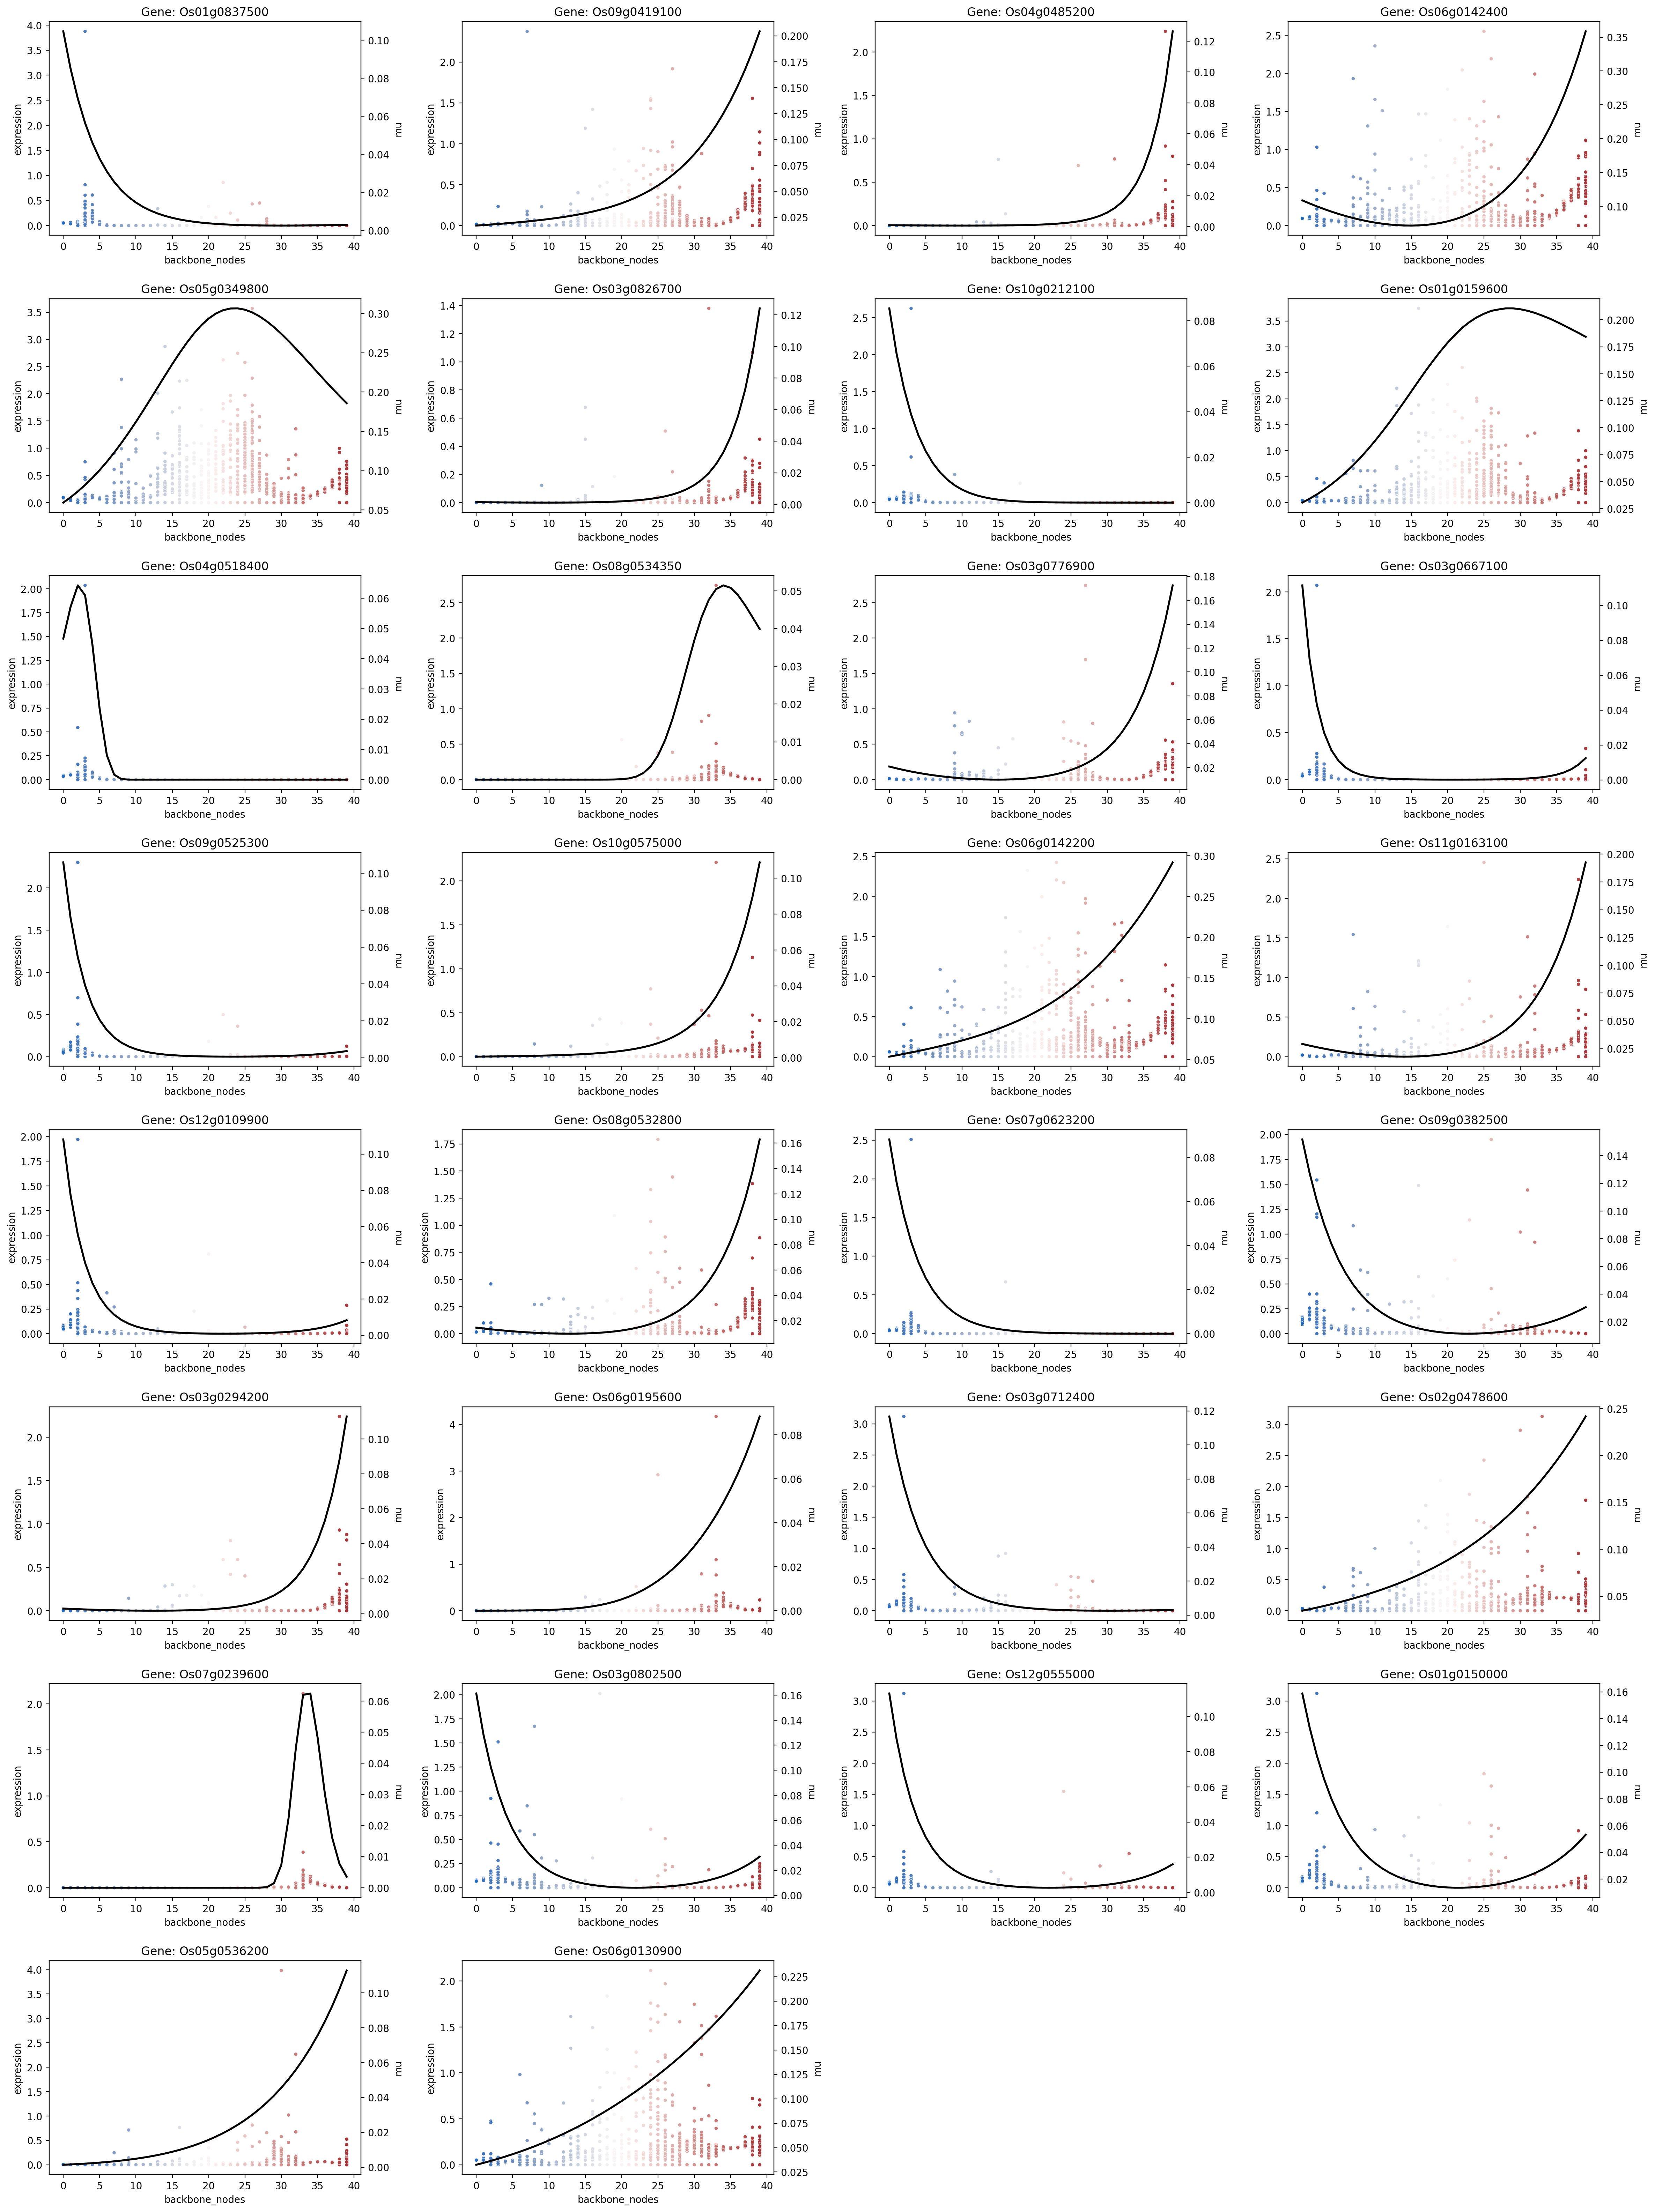

Saving figure to /share/org/ZJUFANJL/zju_shangnm/jobdata/Xterm20250414191113/3DAtlasPRJT/output/VA_side_nocombat_degs_fit_chunk_3.pdf...
Done


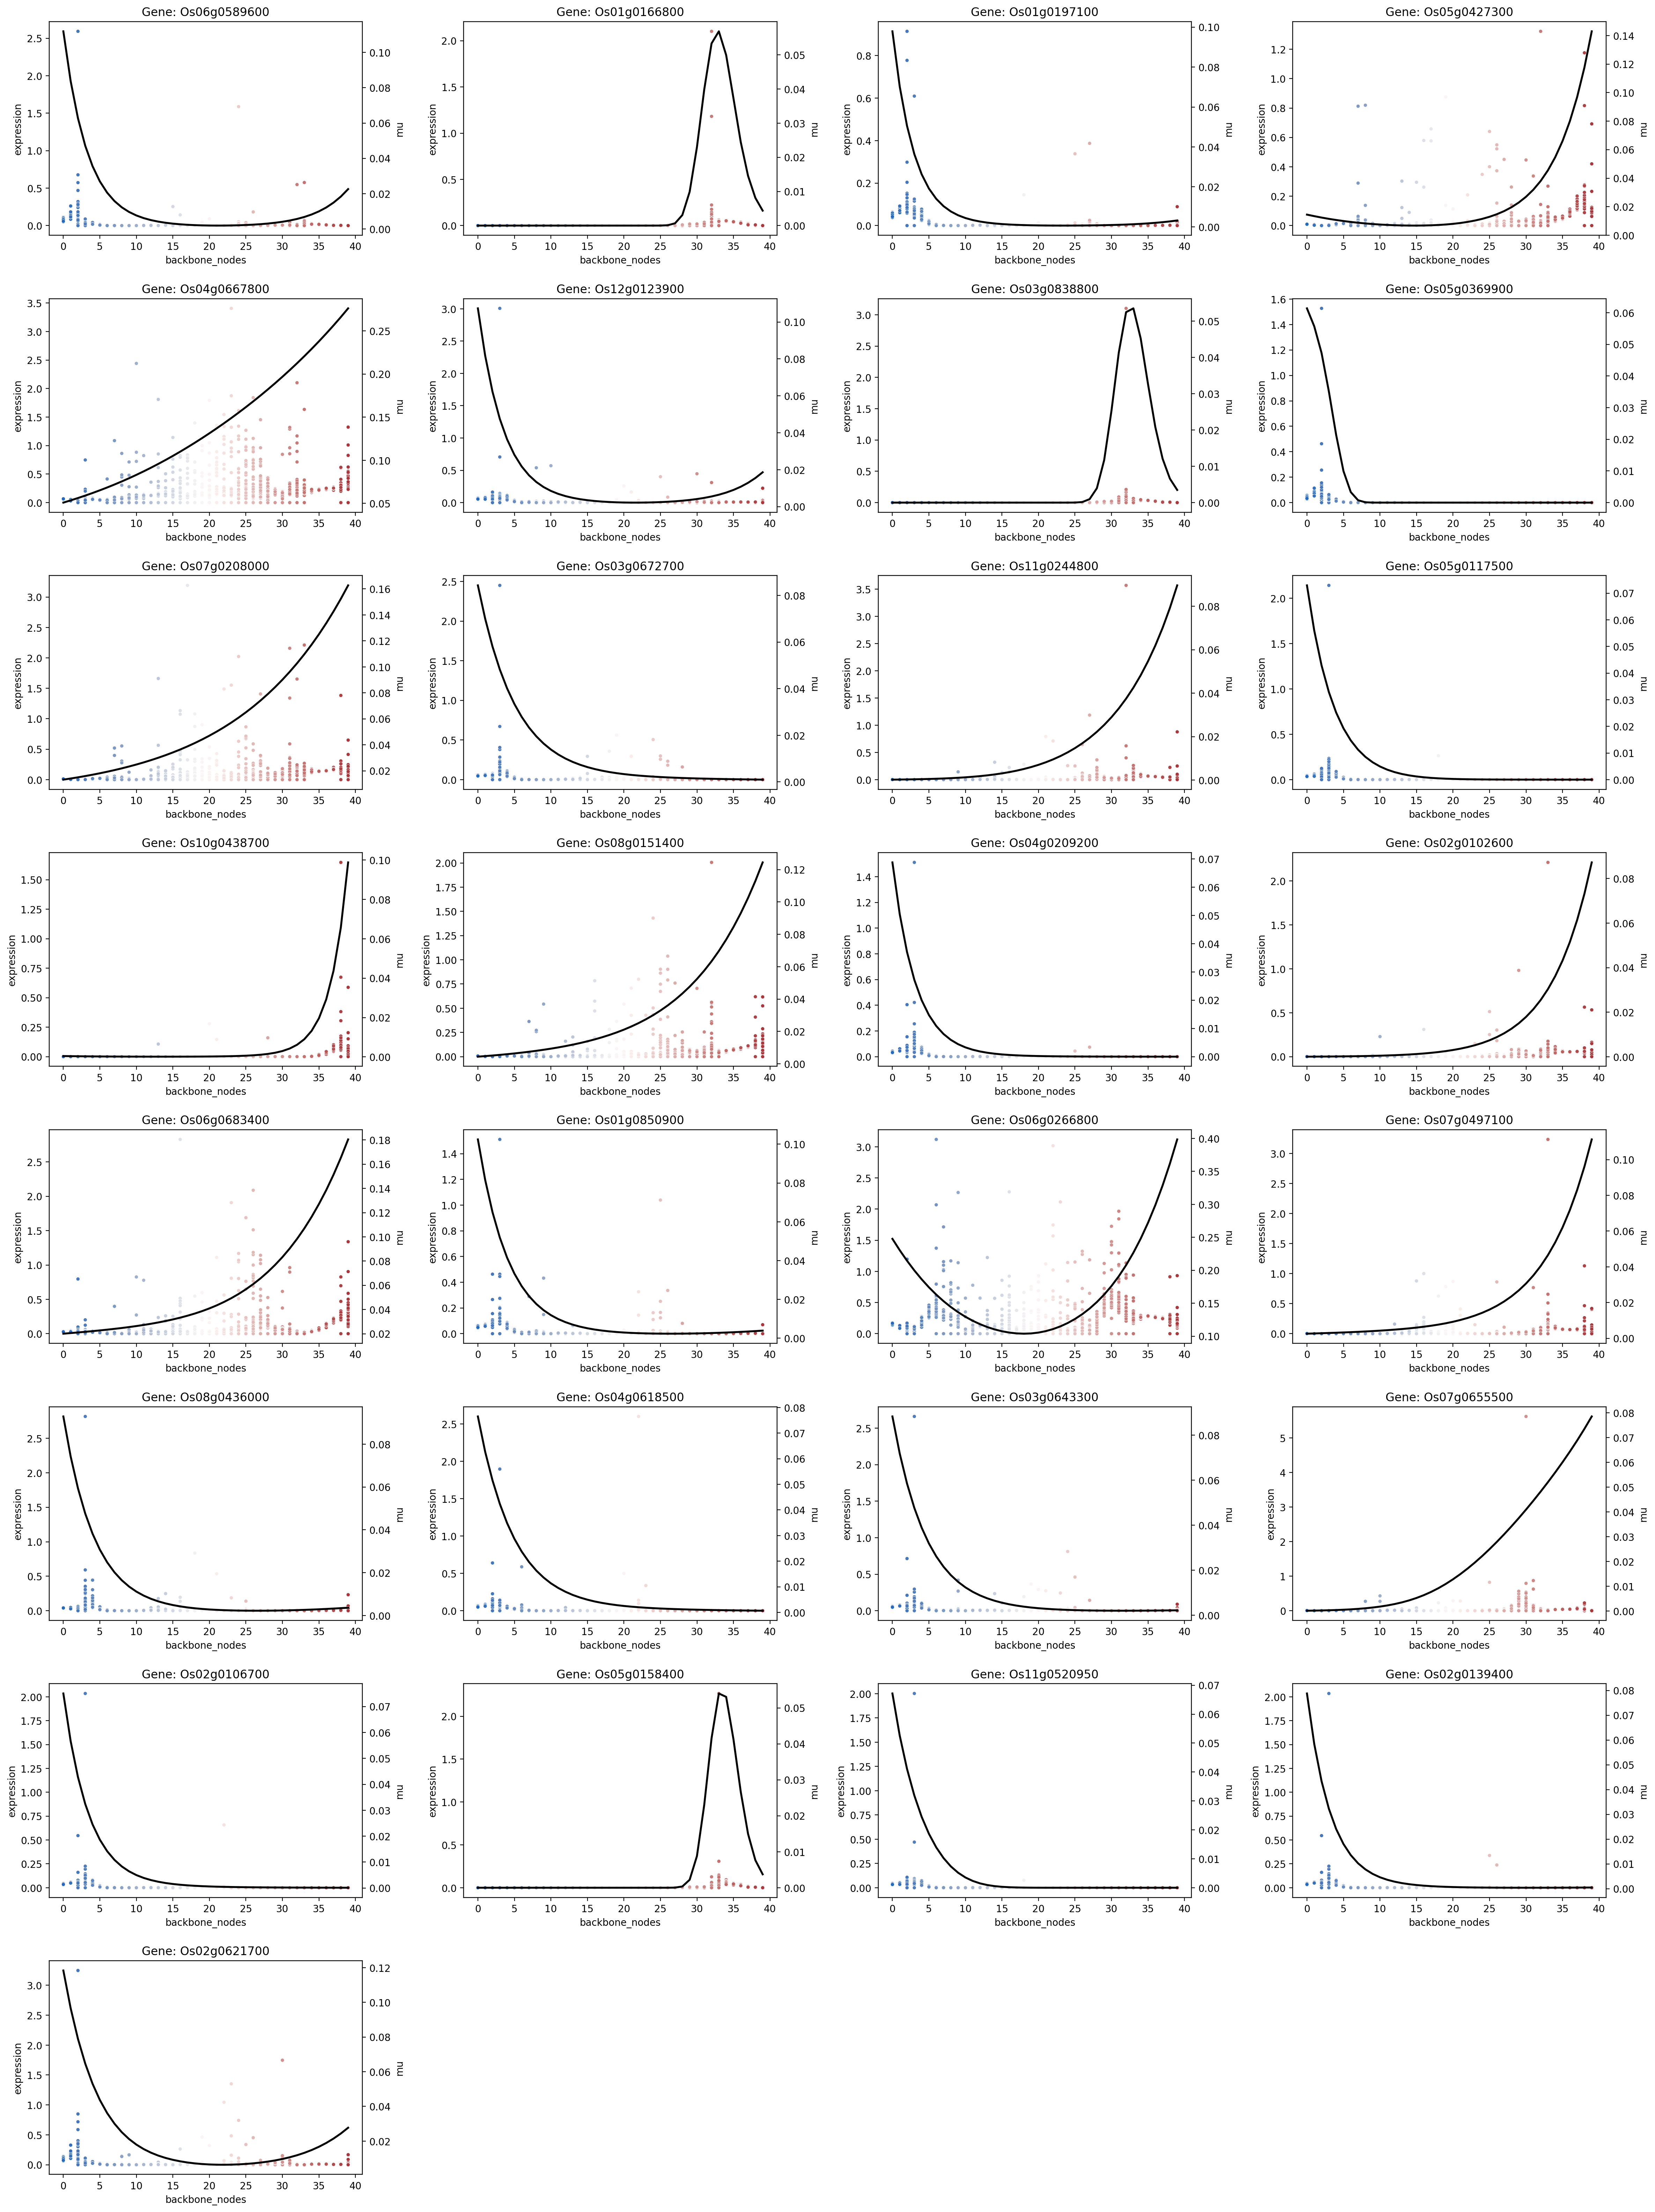

In [ ]:
import numpy as np

# 假设 glm_data.index.tolist() 返回 1500+ 个基因
all_genes = glm_data.index.tolist()
chunk_size = 30  # 每组 100 个

# 使用 numpy.array_split 自动分组
gene_chunks = np.array_split(all_genes, np.ceil(len(all_genes) / chunk_size))

# 遍历每一组，并调用 st.pl.glm_fit
for i, genes in enumerate(gene_chunks):
    st.pl.glm_fit(
        adata=germ_adata,
        genes=genes.tolist(),  # 转回 list（如果是 numpy array）
        ncols=4,
        feature_x="backbone_nodes",
        feature_y="expression",
        color_key="backbone_nodes",
        glm_key="glm_degs",
        show_legend=False,
        save_show_or_return="all",
        save_kwargs=dict(
            path=os.path.join(out_image_path, f"{sample_id}_degs_fit_chunk_{i+1}"),  # 按组编号
            prefix=None,
            ext="pdf",
            dpi=300
        )
    )